## Finalized regression process

### Starter code

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.stats import pearsonr, ttest_ind
from algorithms import mean_squared_error, stochastic_gradient_descent, train_test_split, zscore, apply_weights_and_bias, standard_deviation, optimized_stochastic_gradient_descent, matrix_mean_squared_error, optimized_stochastic_gradient_descent_ridge
import mplcyberpunk


def prepreocess():
    '''
    preprocesss and return data frame depending on 
    if choosen red or white wine
    '''
    file = 'winequality-red.csv'
    df = pd.read_csv(file, sep=';')
    return df

def multiple_linear_regression(df, stochastic_sample_size):
    '''
    run the actual multiple linear regression on red or white wine data
    return a list representing the losses per each epoch
    '''
    train, test = train_test_split(df)
    loss_per_epoch = []

    weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
    weights, bias = stochastic_gradient_descent(train, learning_rate=.0001, weights=weights, bias=bias, epoches=100, min_step_size=0.0001, stochastic_sample_size=stochastic_sample_size, error_over_time=loss_per_epoch)

    test_results = mean_squared_error(weights=weights, bias=bias, df=test)
    return loss_per_epoch, test_results

def optimized_multiple_linear_regression(df, stochastic_sample_size, lr, epoches=100):
    '''
    run an optimized version of multiple linear regression
    '''
    train, test = train_test_split(df)
    loss_per_epoch = []

    weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
    theta = optimized_stochastic_gradient_descent(train, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=loss_per_epoch, stochastic_sample_size=stochastic_sample_size, printProgress=False)

    test_results = mean_squared_error(weights=[theta[0, i] for i in range(theta.shape[1] - 1)], bias=theta[0, len(theta[0]) - 1], df=test)
    return loss_per_epoch, test_results

def graph_trials(results, name, cost=0, time=0, x=None):
    '''
    graph and save trail results for the cost function over trails
    '''
    if x is None:
        x = range(0, len(results))

    # plt.style.use('cyberpunk')
    sns.set_theme()

    fig, ax = plt.subplots()
    ax.plot(x, results)
    ax.set_xlabel('epoches')
    ax.set_ylabel('loss (mse)')
    ax.set_title(f'{name} - epoches vs loss (mse)\ncost: {cost}\ntime: {time}', wrap=True)
    plt.tight_layout()

    # mplcyberpunk.add_glow_effects(gradient_fill=True)
    mplcyberpunk.add_gradient_fill(alpha_gradientglow=.4, gradient_start='bottom')
    fig.savefig(f'results/{name}.png')

### gradient descent with 1000 epoches (instead of 100) (mse = .59)
The most direct way to decrease the cost was to simply have more than 100 epoches.

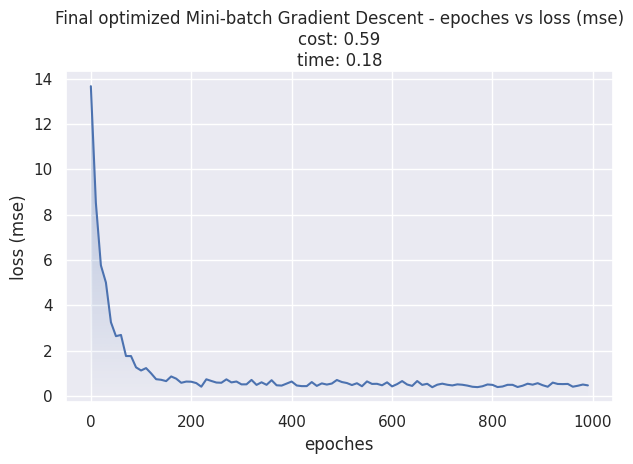

In [17]:
df = prepreocess()

start = time.time()
final_results, cost_final = optimized_multiple_linear_regression(df, .1, lr=.001, epoches=1_000);
final_time = time.time() - start

final_results = final_results[::10]
epoch_number = range(0, 1_000, 10)

graph_trials(final_results, 'Final optimized Mini-batch Gradient Descent', cost = round(cost_final, 2), time = round(final_time, 2), x=epoch_number)

results showed hugely improved the cost going from around 1.12 to .57

### gradient descent without pH, fixed acidity, and residual sugar (mse = .59)
after taking a look at the correlation plot, pH, fixed acidity, and residual sugar have little to no correlation with wine quality so to avoid static they were removed.

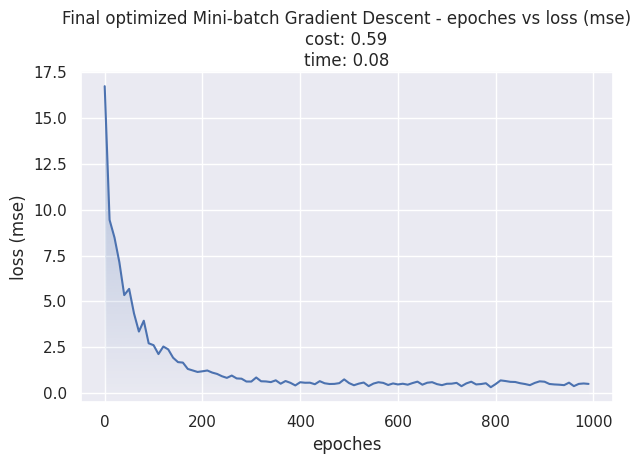

In [18]:
df = prepreocess()
df = df.loc[:, df.columns != 'pH']
df = df.loc[:, df.columns != 'residual sugar']
df = df.loc[:, df.columns != 'fixed acidity']

start = time.time()
final_results, cost_final = optimized_multiple_linear_regression(df, .1, lr=.001, epoches=1_000);
final_time = time.time() - start

final_results = final_results[::10]
epoch_number = range(0, 1_000, 10)

graph_trials(final_results, 'Final optimized Mini-batch Gradient Descent', cost = round(cost_final, 2), time = round(final_time, 2), x=epoch_number)

results showed that costs relativly stayed the same

### standardize features (z score standardization) (mse = .46)
By standardizing features, other features with larger scales will not have more bias over features with smaller scales

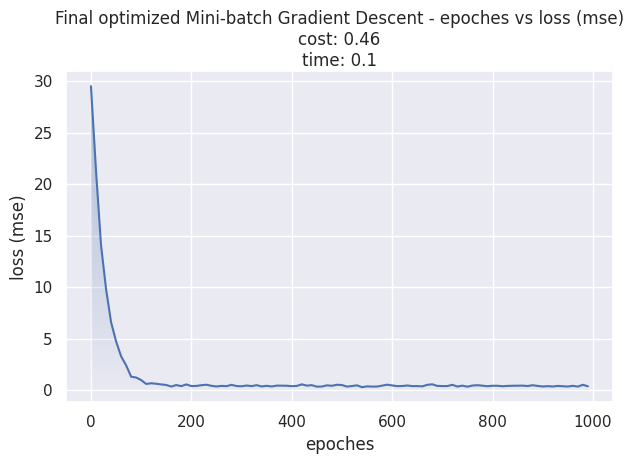

In [19]:
df = prepreocess()
df = df.loc[:, df.columns != 'pH']
df = df.loc[:, df.columns != 'residual sugar']
df = df.loc[:, df.columns != 'fixed acidity']

lr = .1
stochastic_sample_size = .1
epoches = 1_000

train, test = train_test_split(df)

# normalize all training data
parameters = [(train[col].mean(), train[col].std()) for col in train.columns[:-1]]
for col in train.columns[:-1]:
    mean = train[col].mean()
    std_dev = train[col].std()
    def stand(row, mean, std_dev):
        return (row - mean) / std_dev
    train[col] = train[col].apply(stand, args=(mean, std_dev))
# normalize all the test
for i in range(len(train.columns[:-1])):
    col = train.columns[i]
    mean = parameters[i][0]
    std_dev = parameters[i][1]
    def stand(row, mean, std_dev):
        return (row - mean) / std_dev
    test[col] = test[col].apply(stand, args=(mean, std_dev))

start = time.time()
final_results = []
weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
theta = optimized_stochastic_gradient_descent(train, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=final_results, stochastic_sample_size=stochastic_sample_size, printProgress=False)

# find mean squared error
weights = [theta[0, i] for i in range(theta.shape[1] - 1)]
bias = theta[0, theta.shape[1] - 1]
test_results = mean_squared_error(df=test, weights=weights, bias=bias)

final_time = time.time() - start

# plot results
final_results = final_results[::10]
epoch_number = range(0, 1_000, 10)
graph_trials(final_results, 'Final optimized Mini-batch Gradient Descent', cost = round(test_results, 2), time = round(final_time, 2), x=epoch_number)

Cost did significantly drop from .57 to .40 - .45

### Three fold cross validation (cost = .4)

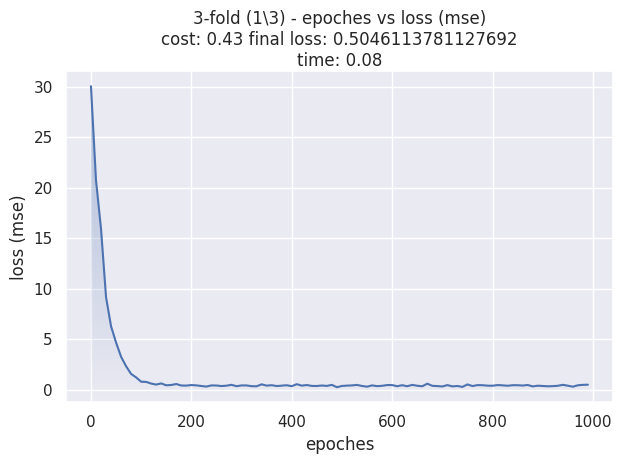

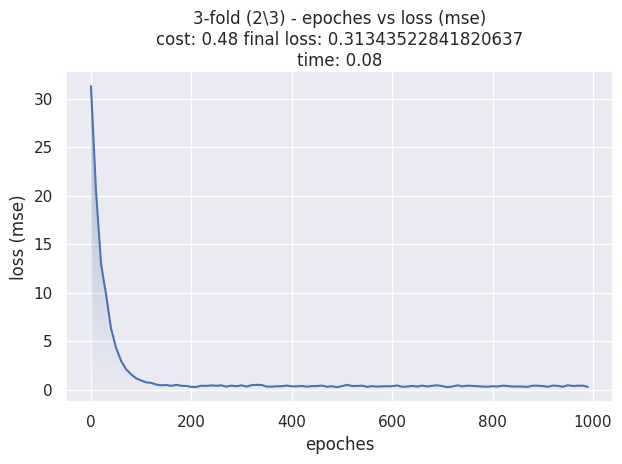

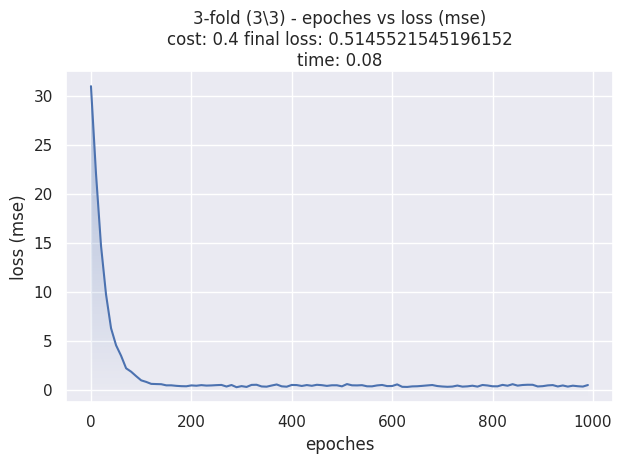

In [20]:
from cross_validation import n_fold_cross_validation

df = prepreocess()
df = df.loc[:, df.columns != 'pH']
df = df.loc[:, df.columns != 'residual sugar']
df = df.loc[:, df.columns != 'fixed acidity']

lr = .1
stochastic_sample_size = .1
epoches = 1_000
n = 3

train_test_sets = n_fold_cross_validation(n=3, df=df)

for i in range(len(train_test_sets)):
    train = train_test_sets[i][0]
    test = train_test_sets[i][1]
    itr = i
    # normalize all training data
    parameters = [(train[col].mean(), train[col].std()) for col in train.columns[:-1]]
    for col in train.columns[:-1]:
        mean = train[col].mean()
        std_dev = train[col].std()
        def stand(row, mean, std_dev):
            return (row - mean) / std_dev
        train[col] = train[col].apply(stand, args=(mean, std_dev))
    # normalize all the test
    for i in range(len(train.columns[:-1])):
        col = train.columns[i]
        mean = parameters[i][0]
        std_dev = parameters[i][1]
        def stand(row, mean, std_dev):
            return (row - mean) / std_dev
        test[col] = test[col].apply(stand, args=(mean, std_dev))

    start = time.time()
    final_results = []
    weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
    theta = optimized_stochastic_gradient_descent(train, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=final_results, stochastic_sample_size=stochastic_sample_size, printProgress=False)

    # find mean squared error
    weights = [theta[0, i] for i in range(theta.shape[1] - 1)]
    bias = theta[0, theta.shape[1] - 1]
    test_results = mean_squared_error(df=test, weights=weights, bias=bias)

    final_time = time.time() - start

    # plot results
    final_results = final_results[::10]
    epoch_number = range(0, 1_000, 10)
    graph_trials(final_results, f'{n}-fold ({itr + 1}\\{n})', cost = f'{round(test_results, 2)} final loss: {final_results[len(final_results) - 1]}', time = round(final_time, 2), x=epoch_number)

### apply ridge (l2) and lasso (l1) to determine good values of lamda (lamda=1)

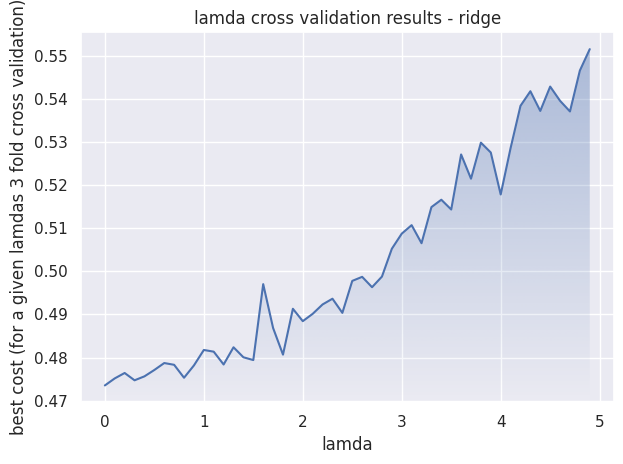

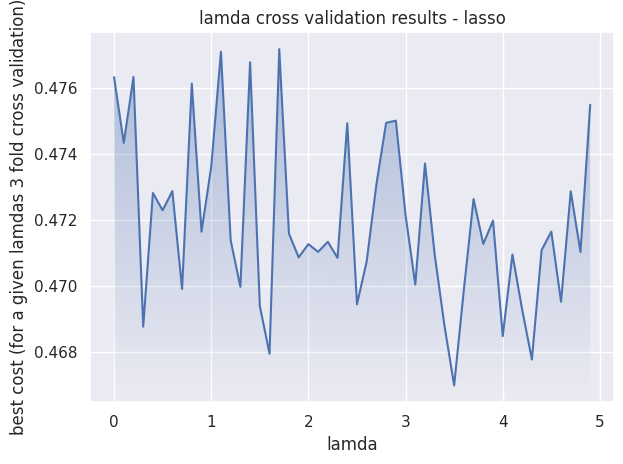

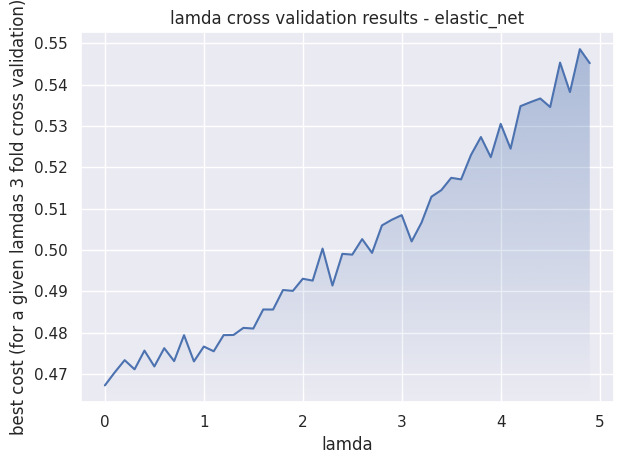

In [26]:
from cross_validation import n_fold_cross_validation
from algorithms import optimized_stochastic_gradient_descent_ridge, optimized_stochastic_gradient_descent_lasso, optimized_stochastic_gradient_descent_elastic_net

df = prepreocess()
# df = df.loc[:, df.columns != 'pH']
# df = df.loc[:, df.columns != 'residual sugar']
# df = df.loc[:, df.columns != 'fixed acidity']

lr = .1
stochastic_sample_size = .1
epoches = 1_000
n = 3

lmdas = []
for i in range(50):
    lmdas.append(i * 0.1)

def test_reg(func, name):
    lmdas_costs = [] # best recorded cost for each lamda of 3 fold validation
    for lmda in lmdas:
        train_test_sets = n_fold_cross_validation(n=3, df=df)
        recorded_costs = []
        for i in range(len(train_test_sets)):
            train = train_test_sets[i][0]
            test = train_test_sets[i][1]
            itr = i
            # normalize all training data
            parameters = [(train[col].mean(), train[col].std()) for col in train.columns[:-1]]
            for col in train.columns[:-1]:
                mean = train[col].mean()
                std_dev = train[col].std()
                def stand(row, mean, std_dev):
                    return (row - mean) / std_dev
                train[col] = train[col].apply(stand, args=(mean, std_dev))
            # normalize all the test
            for i in range(len(train.columns[:-1])):
                col = train.columns[i]
                mean = parameters[i][0]
                std_dev = parameters[i][1]
                def stand(row, mean, std_dev):
                    return (row - mean) / std_dev
                test[col] = test[col].apply(stand, args=(mean, std_dev))

            start = time.time()
            final_results = []
            weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
            # theta = optimized_stochastic_gradient_descent_ridge(train, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=final_results, stochastic_sample_size=stochastic_sample_size, printProgress=False,
            #                                                     lmda=lmda)
            theta = func(train, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=final_results, stochastic_sample_size=stochastic_sample_size, printProgress=False,
                                                                lmda=lmda)

            # find mean squared error
            weights = [theta[0, i] for i in range(theta.shape[1] - 1)]
            bias = theta[0, theta.shape[1] - 1]
            test_results = mean_squared_error(df=test, weights=weights, bias=bias)

            final_time = time.time() - start

            # plot results
            # final_results = final_results[::10]
            # epoch_number = range(0, 1_000, 10)
            # graph_trials(final_results, f'{lmda}-lamda {n}-fold ({itr + 1}\\{n})', cost = f'{round(test_results, 2)} final loss: {final_results[len(final_results) - 1]}', time = round(final_time, 2), x=epoch_number)

            # track results
            recorded_costs.append(test_results)
    
        lmdas_costs.append(max(recorded_costs))

    # plot all results        
    # plt.style.use('cyberpunk')
    sns.set_theme()

    fig, ax = plt.subplots()
    ax.plot(lmdas, lmdas_costs)
    ax.set_xlabel('lamda')
    ax.set_ylabel('best cost (for a given lamdas 3 fold cross validation)')
    ax.set_title(f'lamda cross validation results - {name}', wrap=True)
    plt.tight_layout()

    # mplcyberpunk.add_glow_effects(gradient_fill=True)
    mplcyberpunk.add_gradient_fill(alpha_gradientglow=.4, gradient_start='bottom')
    fig.savefig(f'results/{name}_regression_results.png')

test_reg(optimized_stochastic_gradient_descent_ridge, name='ridge')
test_reg(optimized_stochastic_gradient_descent_lasso, name='lasso')
test_reg(optimized_stochastic_gradient_descent_elastic_net, name='elastic_net')

### apply elastic net regression with lamda = 1 (mse = .34)

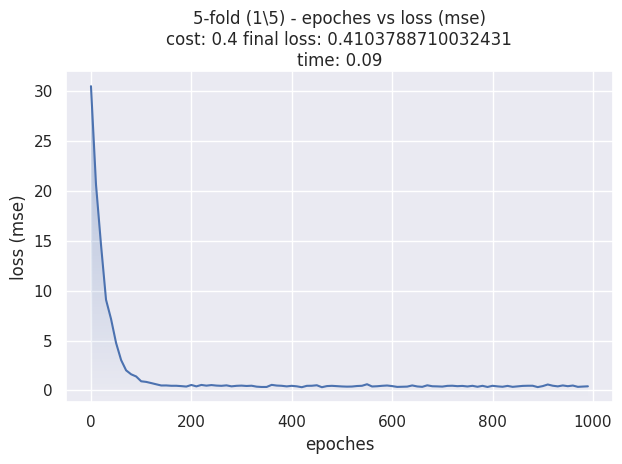

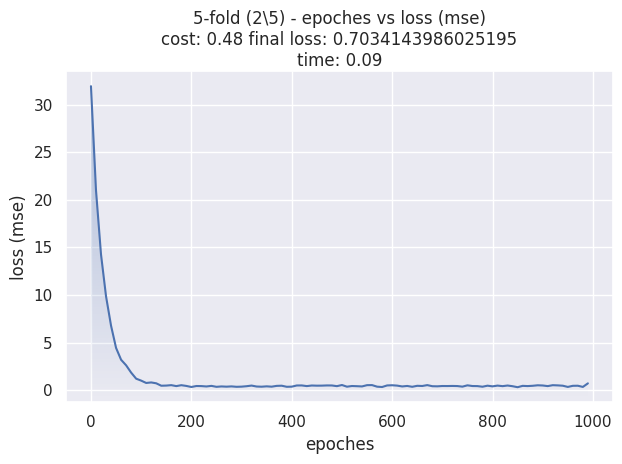

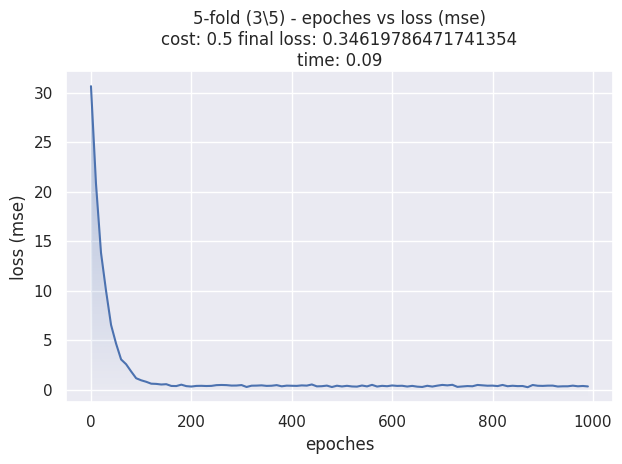

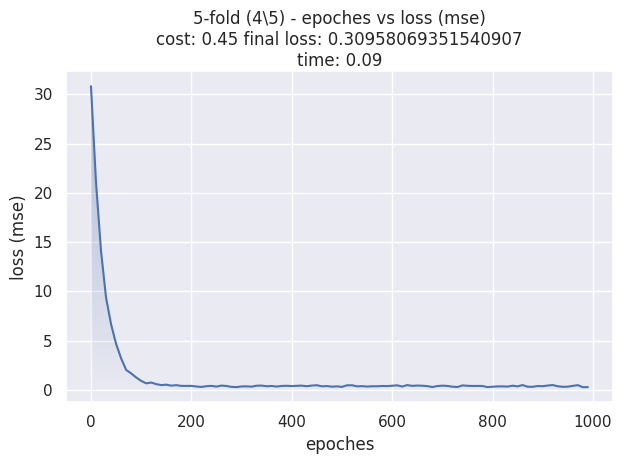

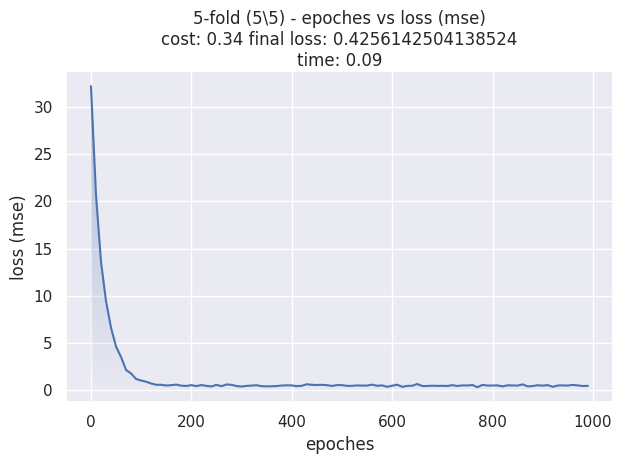

In [27]:
from algorithms import optimized_stochastic_gradient_descent_ridge, optimized_stochastic_gradient_descent_lasso, optimized_stochastic_gradient_descent_elastic_net
from cross_validation import n_fold_cross_validation

df = prepreocess()
df = df.loc[:, df.columns != 'pH']
df = df.loc[:, df.columns != 'residual sugar']
df = df.loc[:, df.columns != 'fixed acidity']

lr = .1
stochastic_sample_size = .1
epoches = 1_000
n = 5

train_test_sets = n_fold_cross_validation(n=n, df=df)

for i in range(len(train_test_sets)):
    train = train_test_sets[i][0]
    test = train_test_sets[i][1]
    itr = i
    # normalize all training data
    parameters = [(train[col].mean(), train[col].std()) for col in train.columns[:-1]]
    for col in train.columns[:-1]:
        mean = train[col].mean()
        std_dev = train[col].std()
        def stand(row, mean, std_dev):
            return (row - mean) / std_dev
        train[col] = train[col].apply(stand, args=(mean, std_dev))
    # normalize all the test
    for i in range(len(train.columns[:-1])):
        col = train.columns[i]
        mean = parameters[i][0]
        std_dev = parameters[i][1]
        def stand(row, mean, std_dev):
            return (row - mean) / std_dev
        test[col] = test[col].apply(stand, args=(mean, std_dev))

    start = time.time()
    final_results = []
    weights, bias = [0 for i in range(len(df.columns) - 1)], 0.0
    theta = optimized_stochastic_gradient_descent_elastic_net(train, lmda=1, lr=lr, weights=weights, bias=bias, epoches=epoches, min_step_size=0, error_over_time=final_results, stochastic_sample_size=stochastic_sample_size, printProgress=False)

    # find mean squared error
    weights = [theta[0, i] for i in range(theta.shape[1] - 1)]
    bias = theta[0, theta.shape[1] - 1]
    test_results = mean_squared_error(df=test, weights=weights, bias=bias)

    final_time = time.time() - start

    # plot results
    final_results = final_results[::10]
    epoch_number = range(0, 1_000, 10)
    graph_trials(final_results, f'{n}-fold ({itr + 1}\\{n})', cost = f'{round(test_results, 2)} final loss: {final_results[len(final_results) - 1]}', time = round(final_time, 2), x=epoch_number)